In [4]:
import sys
import pickle
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

from models.bulge_models import BulgeTemplates
from models.templates import LorimerDiskTemplate
from models.np_model import NPModel

%load_ext autoreload
%autoreload 2

In [5]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist

In [6]:
import healpy as hp
import matplotlib.pyplot as plt
import arviz as az

In [116]:
r_outer = 25
l_max = 2

vary_disk = True
vary_gamma = True
bulge_hybrid = True

ps_cat = "3fgl"
nside = 128

npmodel = NPModel(r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=7500, guide="iaf_mixture", lr=3e-4)

Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|██████████| 7500/7500 [07:48<00:00, 16.01it/s, init loss: 35032.5825, avg. loss [7126-7500]: 20102.5271]


In [117]:
posterior = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=50000)

In [1]:
posterior_bulge = {}
for key in list(posterior.keys()):
    if "theta" in key:
        posterior_bulge[key] = posterior[key]
        posterior.pop(key, None)

In [119]:
az.summary(posterior)

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Alm_0,-0.028,0.023,-0.050,0.017,0.000,0.000,49606.0,50008.0,NaN
Alm_1,0.006,0.032,-0.043,0.050,0.000,0.000,49920.0,49545.0,NaN
Alm_2,-0.034,0.016,-0.050,-0.002,0.000,0.000,48636.0,49715.0,NaN
Alm_3,-0.006,0.029,-0.047,0.040,0.000,0.000,50179.0,49961.0,NaN
Alm_4,0.036,0.014,0.008,0.050,0.000,0.000,50345.0,50339.0,NaN
Alm_5,-0.015,0.027,-0.048,0.032,0.000,0.000,47918.0,49382.0,NaN
C,3.283,0.684,2.153,4.490,0.003,0.002,49583.0,48518.0,NaN
S_bub,1.159,0.061,1.046,1.273,0.000,0.000,50638.0,49574.0,NaN
S_dif,11.386,0.104,11.201,11.568,0.000,0.000,49616.0,49221.0,NaN
S_gce,0.967,0.276,0.489,1.463,0.001,0.001,49759.0,49501.0,NaN


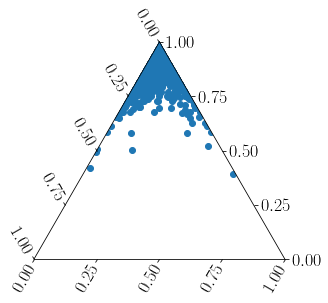

In [122]:
import mpltern

ax = plt.subplot(projection='ternary')
ax.scatter(*posterior_bulge['theta_ics'].T)     

In [123]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_ics'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.973,0.040,0.898,1.000,0.0,0.0,50301.0,49571.0,NaN
1,0.016,0.031,0.000,0.074,0.0,0.0,50378.0,49707.0,NaN
2,0.011,0.026,0.000,0.054,0.0,0.0,50288.0,49293.0,NaN


In [124]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_pibrem'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.813,0.070,0.684,0.927,0.0,0.0,50538.0,50212.0,NaN
1,0.148,0.071,0.028,0.281,0.0,0.0,50062.0,49908.0,NaN
2,0.038,0.048,0.000,0.132,0.0,0.0,50342.0,49388.0,NaN


## Config scan

In [6]:
import numpy as np

ps_cat = "3fgl"
r_outer = 25

# for nside in [128]:
#     for config in ["000","100","110","111"]:
#         for l_max in [0, 3]:
for nside in [256]:
    for config in ["111"]:
        for l_max in [3]:

            vary_disk = int(config[0])
            vary_gamma = int(config[1])
            bulge_hybrid = int(config[2])

            npmodel = NPModel(r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
            svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(np.random.randint(1000)), n_steps=15_000, guide="iaf", lr=2e-4)

            posterior = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(np.random.randint(1000)), num_samples=50000)
            posterior['logZ'] = np.array(jnp.mean(svi_results.losses[-250:]))  # Save log-evidence estimate

            posterior_file = "../data/posteriors/posterior_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}_ps_{}_nside_{}.p".format(r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma, ps_cat, nside)

            # Save data (serialize)
            with open(posterior_file, 'wb') as outfile:
                pickle.dump(posterior, outfile, protocol=pickle.HIGHEST_PROTOCOL)

            # Load data (deserialize)
            with open(posterior_file, 'rb') as handle:
                posterior = pickle.load(handle)

## Table

In [8]:
def get_latex_unc(samples, add_perc=True):
    percentiles = np.percentile(samples, [18, 50, 64])
    m = "{:.2f}".format(percentiles[1])
    u = "{:.2f}".format(percentiles[2] - percentiles[1])
    l = "{:.2f}".format(percentiles[1] - percentiles[0])

    return ("${0}^{{+{1}}}_{{-{2}}}\%$".format(m, u, l) if add_perc else "${0}^{{+{1}}}_{{-{2}}}$".format(m, u, l))

In [9]:
r_outer = 25
l_max = 0
ps_cat = "3fgl"

print(r"{C{1.2cm}C{1.6cm}|C{1.6cm}C{1.6cm}C{1.6cm}C{1.6cm}|C{1.6cm}C{1.6cm}C{1.6cm}C{1.6cm}C{1.6cm}|C{2cm}|C{1.5cm}}")
print(r"\toprule")
print(r"\toprule")
print(r"\textbf{nside} & $\ell_\mathrm{max}$ & {\textbf{GCE [\%]}} & \textbf{GCE PS / GCE} & \textbf{Disk [\%]} & \textbf{GCE + Disk [\%]} & $z_{\mathrm s}$ [kpc] & $\gamma_\mathrm{Poiss}$ & $\gamma_\mathrm{PS}$ & $f^\mathrm{Bulge}_\mathrm{Poiss}$ & $f^\mathrm{Bulge}_\mathrm{PS}$ & $\log\mathcal Z$ & $\Delta\log\mathcal Z$ \\")
print(r"\hline")
# for nside in [128]:
#     for config in ["000","100","110","111"]:
#         for l_max in [0, 3]:
# for nside in [256]:
#     for config in ["000"]:
#         for l_max in [0]:
for nside in [128]:
    for config in ["111"]:
        for l_max in [3]:

            vary_disk = int(config[0])
            vary_gamma = int(config[1])
            bulge_hybrid = int(config[2])
            
            posterior_file = "../data/posteriors/posterior_r_{}_lmax_{}_vary_disk_{}_bulge_hybrid_{}_vary_gamma_{}_ps_{}_nside_{}.p".format(r_outer, l_max, vary_disk, bulge_hybrid, vary_gamma, ps_cat, nside)

            # Load data (deserialize)
            with open(posterior_file, 'rb') as handle:
                posterior = pickle.load(handle)
                
            posterior_bulge = {}
            for key in list(posterior.keys()):
                if "theta" in key:
                    posterior_bulge[key] = posterior[key]
                    posterior.pop(key, None)

            S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])
            S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])
            
            flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]
            
            flux_fraction_gce = get_latex_unc(flux_fraction_post[np.argwhere(S_labels == 'Sps_gce')[0,0]] * 100 + flux_fraction_post[np.argwhere(S_labels == 'S_gce')[0,0]] * 100, add_perc=False)
            flux_fraction_gceps = get_latex_unc(flux_fraction_post[np.argwhere(S_labels == 'Sps_gce')[0,0]] * 100 / (flux_fraction_post[np.argwhere(S_labels == 'Sps_gce')[0,0]] * 100 + flux_fraction_post[np.argwhere(S_labels == 'S_gce')[0,0]] * 100), add_perc=False)
            flux_fraction_dskps = get_latex_unc(flux_fraction_post[np.argwhere(S_labels == 'Sps_dsk')[0,0]] * 100, add_perc=False)
            flux_fraction_gcedsk = get_latex_unc(flux_fraction_post[np.argwhere(S_labels == 'Sps_dsk')[0,0]] * 100 + flux_fraction_post[np.argwhere(S_labels == 'Sps_gce')[0,0]] * 100 + flux_fraction_post[np.argwhere(S_labels == 'S_gce')[0,0]] * 100, add_perc=False)
            
            if vary_gamma:
                post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])
                gamma_poiss = get_latex_unc(post[0], add_perc=False)
                gamma_ps = get_latex_unc(post[1], add_perc=False)
            else:
                gamma_poiss = gamma_ps = "--"
                
            if bulge_hybrid:
                post = np.array([v for k,v in posterior.items() if k.startswith('f_bulge')])
                f_bulge_poiss = get_latex_unc(post[0], add_perc=False)
                f_bulge_ps = get_latex_unc(post[1], add_perc=False)
            else:
                f_bulge_poiss = f_bulge_ps = "--"

            if vary_disk:
                post = np.array([v for k,v in posterior.items() if k.startswith('zs')])
                zs = get_latex_unc(post[0], add_perc=False)
            else:
                zs = zs = "--"
                
            if config == "000" and l_max == 0:
                logZ_base = posterior['logZ']
            delta_logZ = posterior['logZ'] - logZ_base

            print(r"{} & {} & {} & {} & {} & {} & {} & {} & {} & {} & {} & {:.6g} & {:.6g} \\".format(nside, l_max, flux_fraction_gce, flux_fraction_gceps, flux_fraction_dskps, flux_fraction_gcedsk, zs, gamma_poiss, gamma_ps, f_bulge_poiss, f_bulge_ps, -posterior['logZ'], -delta_logZ))
                
print(r"\bottomrule")

{C{1.2cm}C{1.6cm}|C{1.6cm}C{1.6cm}C{1.6cm}C{1.6cm}|C{1.6cm}C{1.6cm}C{1.6cm}C{1.6cm}C{1.6cm}|C{2cm}|C{1.5cm}}
\toprule
\toprule
\textbf{nside} & $\ell_\mathrm{max}$ & {\textbf{GCE [\%]}} & \textbf{GCE PS / GCE} & \textbf{Disk [\%]} & \textbf{GCE + Disk [\%]} & $z_{\mathrm s}$ [kpc] & $\gamma_\mathrm{Poiss}$ & $\gamma_\mathrm{PS}$ & $f^\mathrm{Bulge}_\mathrm{Poiss}$ & $f^\mathrm{Bulge}_\mathrm{PS}$ & $\log\mathcal Z$ & $\Delta\log\mathcal Z$ \\
\hline


NameError: name 'logZ_base' is not defined

In [10]:
az.summary(posterior)

arviz - WARNING - Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Array contains NaN-value.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Alm_0,-0.022,0.024,-0.050,0.026,0.000,0.000,48707.0,49462.0,NaN
Alm_1,0.008,0.029,-0.041,0.050,0.000,0.000,50564.0,50055.0,NaN
Alm_10,-0.033,0.015,-0.050,-0.004,0.000,0.000,49844.0,47414.0,NaN
Alm_11,0.019,0.025,-0.028,0.050,0.000,0.000,49887.0,48305.0,NaN
Alm_2,-0.029,0.018,-0.050,0.007,0.000,0.000,49747.0,49346.0,NaN
Alm_3,0.003,0.029,-0.043,0.049,0.000,0.000,48744.0,49125.0,NaN
Alm_4,0.031,0.018,-0.005,0.050,0.000,0.000,49860.0,49266.0,NaN
Alm_5,-0.009,0.028,-0.049,0.039,0.000,0.000,48560.0,49568.0,NaN
Alm_6,-0.032,0.019,-0.050,0.005,0.000,0.000,50217.0,49218.0,NaN
Alm_7,0.006,0.027,-0.039,0.049,0.000,0.000,49479.0,48932.0,NaN


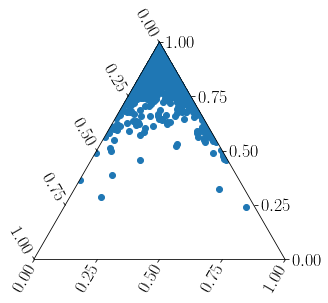

In [11]:
import mpltern

ax = plt.subplot(projection='ternary')
ax.scatter(*posterior_bulge['theta_ics'].T)   

## Plots for GI proposal

In [12]:
from getdist import plots, MCSamples
import getdist

In [13]:
zs_post = np.array([v for k,v in posterior.items() if k.startswith('zs')])[:, :]
C_post = np.array([v for k,v in posterior.items() if k.startswith('C')])[:, :]
gamma_post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])[:, :]
f_post = np.array([v for k,v in posterior.items() if k.startswith('f_')])[:1, :]

In [14]:
post_plot = np.concatenate([gamma_post, f_post, zs_post, C_post], axis=0)

Removed no burn in


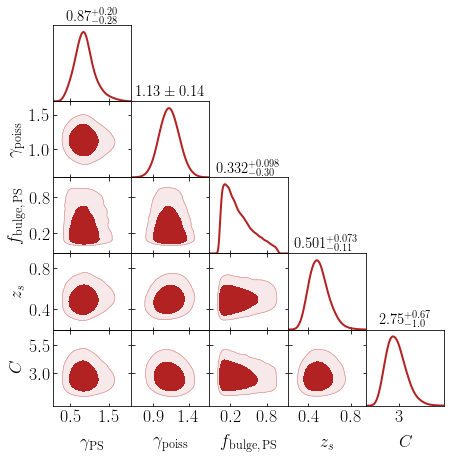

In [15]:
g = plots.get_subplot_plotter(subplot_size=1.4)
g.settings.axes_fontsize=16
g.settings.fontsize=16
g.settings.rc_sizes(axes_fontsize=22, lab_fontsize=22)
g.settings.alpha_filled_add=0.4
g.settings.title_limit_fontsize=19
g.settings.title_limit=1
g.settings.title_limit_labels=0
g.settings.solid_contour_palefactor = 0.9

names = [r'\gamma_\mathrm{PS}', r'\gamma_\mathrm{poiss}', r'f_\mathrm{bulge,\,PS}', r'z_s', r'C']
samples = MCSamples(samples=post_plot.T, names = names, labels = names)

g.triangle_plot([samples],
    line_args=[{'lw':2, 'color':'firebrick'}],
    filled=True,
    # title_limit=1,
    contour_colors=['firebrick'],)

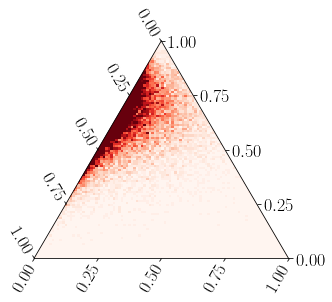

In [86]:
ax = plt.subplot(projection='ternary')
ax.hist2d(*posterior_bulge['theta_pibrem'].T, bins=100, cmap='Reds', vmax=20, density=True);

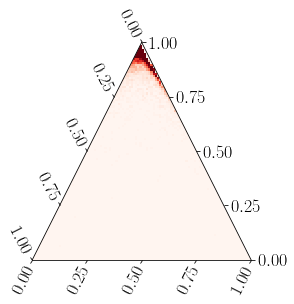

In [87]:
ax = plt.subplot(projection='ternary')
ax.hist3d(*posterior_bulge['theta_ics'].T, bins=75, cmap='Reds', vmax=20, density=True);